# Airy Function Analytical Solution vs Numerical Methods

**Profile:**  $\varepsilon_r(z) = \varepsilon_0 + (1-\varepsilon_0)\,|z/\delta|$ for $|z|\le\delta$; $\varepsilon_r=1$ outside.

Two cases: $\varepsilon_0 = 5$ (dielectric lens, no turning points) and $\varepsilon_0 = -3$ (metallic core, two turning points at $|z|=3\delta/4$).

Parameters: $\delta = 2\lambda_0$, domain $[-4\lambda_0, 4\lambda_0]$, θ = 45°, TE.

Methods compared:
- **Airy** — exact analytical solution (piecewise Airy functions + plane waves)
- **ODE Heun** — 2nd-order Runge–Kutta, fixed step
- **ODE Dopri5** — 5th-order Dormand–Prince, adaptive step
- **FEM P1** — linear finite elements (2nd-order)
- **FEM P2** — quadratic finite elements (4th-order)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import jax
jax.config.update("jax_enable_x64", True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print("Using GPU:", jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print("GPU not available, using CPU.", flush=True)
print(jax.local_device_count(), flush=True)
print(jax.devices(), flush=True)

import jax.numpy as jnp
from jax import jit, vmap

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from airy_solution import solve_v_profile, full_field_v_profile
from main import HelmholtzSolver1D

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
2
[CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
2
[CudaDevice(id=0), CudaDevice(id=1)]


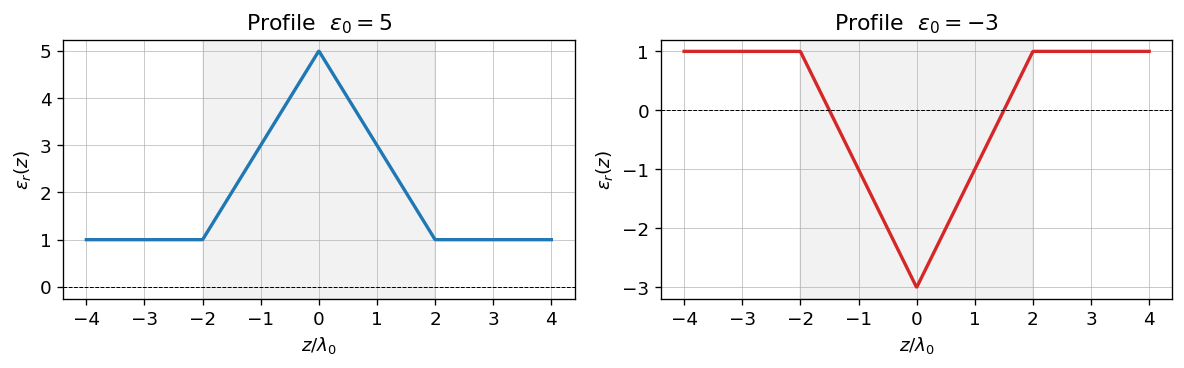

In [2]:
# ── Problem parameters ───────────────────────────────────────────────────────
lambda0 = 1.0
delta   = 2.0 * lambda0          # half-width of transition layer
k0      = 2.0 * np.pi / lambda0
z1, z2  = -delta, delta
z_dom   = np.linspace(-4*lambda0, 4*lambda0, 4000)   # plot domain
z_trans = np.linspace(z1, z2, 2000)                  # reference grid in layer

EPS0_CASES = [5, -3]
CASE_LABELS = {5: r'$\varepsilon_0=5$', -3: r'$\varepsilon_0=-3$'}
CASE_COLORS = {5: '#1f77b4', -3: '#d62728'}

def eps_func_v(eps0, delta):
    """Return a callable eps(z) for the V-shaped profile."""
    def _f(z):
        z = float(z)
        if abs(z) <= delta:
            return eps0 + (1.0 - eps0) * abs(z / delta)
        return 1.0
    return _f

# ── Profile visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=False)
for ax, eps0 in zip(axes, EPS0_CASES):
    eps_f = eps_func_v(eps0, delta)
    zp = np.linspace(-4*lambda0, 4*lambda0, 800)
    ep = np.array([eps_f(z) for z in zp])
    ax.plot(zp/lambda0, ep.real, color=CASE_COLORS[eps0], lw=2)
    ax.axvspan(-delta/lambda0, delta/lambda0, alpha=0.1, color='gray')
    ax.axhline(0, lw=0.6, ls='--', color='k')
    ax.set_xlabel(r'$z/\lambda_0$')
    ax.set_ylabel(r'$\varepsilon_r(z)$')
    ax.set_title(f'Profile  {CASE_LABELS[eps0]}')
    ax.grid(True, lw=0.4)
plt.tight_layout()
plt.savefig('profile.png', bbox_inches='tight')
plt.show()

## Analytical Airy-function solutions

In [3]:
airy_sols = {}   # eps0 → solve_v_profile result
airy_fields = {} # eps0 → field array on z_dom

# ── Airy reference at θ = 45° ────────────────────────────────────────────────
THETA_CONV = 45.0
kx_conv    = k0 * np.sqrt(1.0) * np.sin(np.deg2rad(THETA_CONV))  # eps1 = 1
for eps0 in EPS0_CASES:
    sol = solve_v_profile(eps0, delta, k0 ,kx_conv)
    F   = full_field_v_profile(z_dom, eps0, delta, k0, sol=sol,kx=kx_conv)
    airy_sols[eps0]   = sol
    airy_fields[eps0] = F
    print(f'eps0={eps0:+d}: r={sol["r"]:.4f}, t={sol["t"]:.4f}, '
          f'R={abs(sol["r"])**2:.4f}, T={abs(sol["t"])**2:.4f}, '
          f'R+T={abs(sol["r"])**2 + abs(sol["t"])**2:.6f}')

eps0=+5: r=0.0404+0.0416j, t=0.7165-0.6952j, R=0.0034, T=0.9966, R+T=1.000000
eps0=-3: r=0.9941-0.1083j, t=0.0000-0.0000j, R=1.0000, T=0.0000, R+T=1.000000


## Numerical solutions (ODE + FEM) for both cases

In [4]:
RES_FIELD = 60    # cells per lambda0 for field comparison plots

num_results = {}  # eps0 → dict of method_key → result

for eps0 in EPS0_CASES:
    print(f'\n=== eps0 = {eps0} ===')
    eps_f = eps_func_v(eps0, delta)
    sv = HelmholtzSolver1D(eps_f, z1, z2, theta_deg=THETA_CONV, pol='S', lambda0=lambda0)

    res_ext = max(10, RES_FIELD // 4)
    results = {}

    results['ODE Heun']   = sv.solve_ode(res_trans=RES_FIELD, res_ext=res_ext,
                                          solver_name='Heun', fixed_step=True)
    results['ODE Dopri5'] = sv.solve_ode(res_trans=RES_FIELD, res_ext=res_ext,
                                          solver_name='Dopri5')
    results['FEM P1']     = sv.solve_fem(res_trans=RES_FIELD, res_ext=res_ext, order=1)
    results['FEM P2']     = sv.solve_fem(res_trans=RES_FIELD, res_ext=res_ext, order=2)

    num_results[eps0] = results
    print(f'  Airy:     r={airy_sols[eps0]["r"]:.4f}, t={airy_sols[eps0]["t"]:.4f}')
    for k, v in results.items():
        print(f'  {k:<12}: r={v["r"]:.4f}, t={v["t"]:.4f}')


=== eps0 = 5 ===
HelmholtzSolver1D: pol=S, θ=45.0°, λ₀=1.0, ε₁=1+0j, ε₂=1+0j, kz1=4.443+0j, kz2=4.443+0j
  → ODE res_trans=60.00/λ₀ → n_trans=240
[ODE/Heun] r = 0.0246∠34.6°, t = 0.9727∠-55.4°
  → ODE res_trans=60.00/λ₀ → n_trans=240
[ODE/Dopri5] r = 0.0580∠45.9°, t = 0.9983∠-44.1°
  → FEM res_trans=60.00/λ₀ → n_trans=240,  res_ext=15.00/λ₀ → n_ext=30
[FEM] r = 0.0914∠63.9°, t = 0.9991∠-39.5°
  → FEM res_trans=60.00/λ₀ → n_trans=240,  res_ext=15.00/λ₀ → n_ext=30
[FEM] r = 0.0581∠45.9°, t = 0.9983∠-44.1°
  Airy:     r=0.0404+0.0416j, t=0.7165-0.6952j
  ODE Heun    : r=0.0202+0.0140j, t=0.5523-0.8007j
  ODE Dopri5  : r=0.0404+0.0416j, t=0.7165-0.6952j
  FEM P1      : r=0.0403+0.0820j, t=0.7705-0.6360j
  FEM P2      : r=0.0404+0.0417j, t=0.7165-0.6952j

=== eps0 = -3 ===
HelmholtzSolver1D: pol=S, θ=45.0°, λ₀=1.0, ε₁=1+0j, ε₂=1+0j, kz1=4.443+0j, kz2=4.443+0j
  → ODE res_trans=60.00/λ₀ → n_trans=240
[ODE/Heun] r = 1.0000∠-6.3°, t = 0.0000∠-96.3°
  → ODE res_trans=60.00/λ₀ → n_trans=240
[OD

## Field comparison plots

Each figure shows one field quantity for both $\varepsilon_0$ values side by side.
Gray shading marks the transition layer $[-\delta, \delta]$.

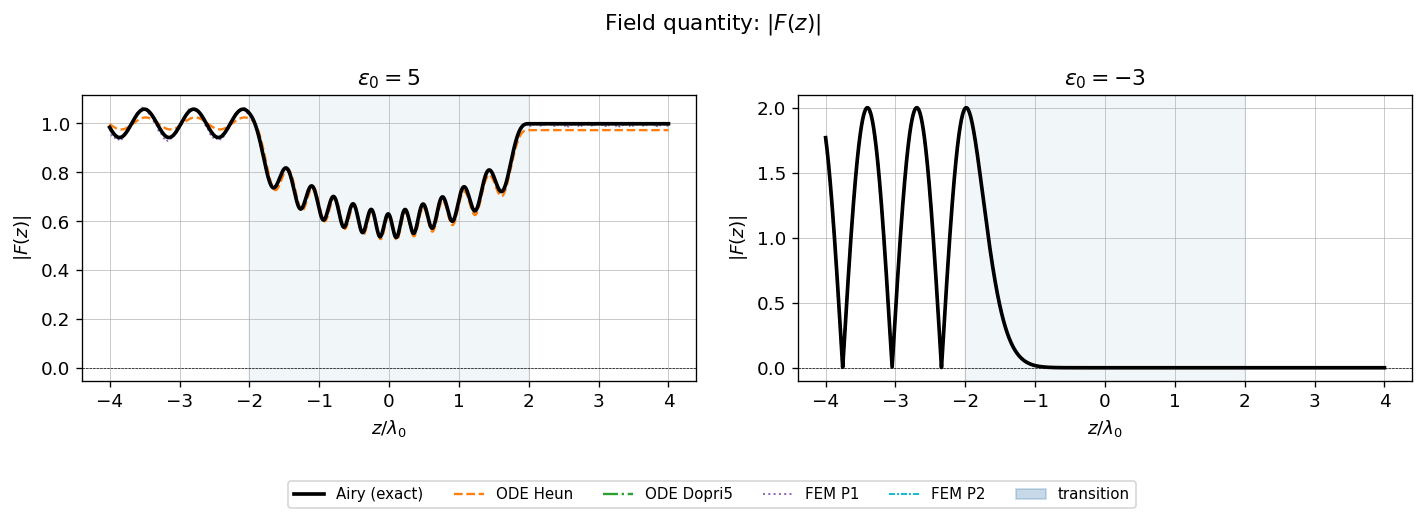

Saved field_abs.png


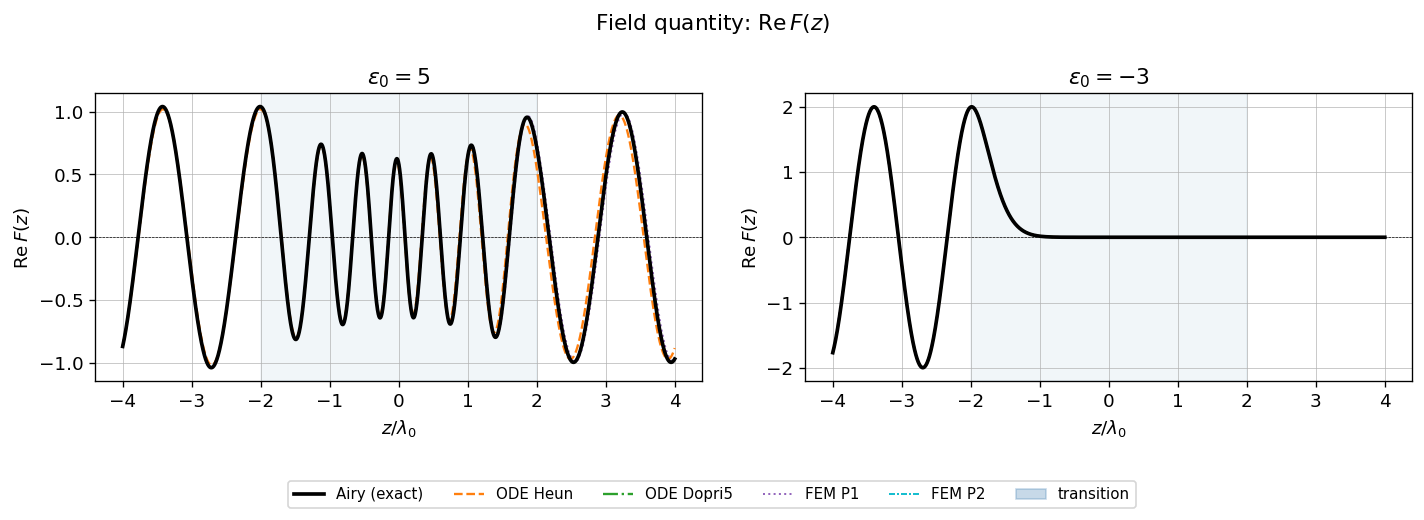

Saved field_real.png


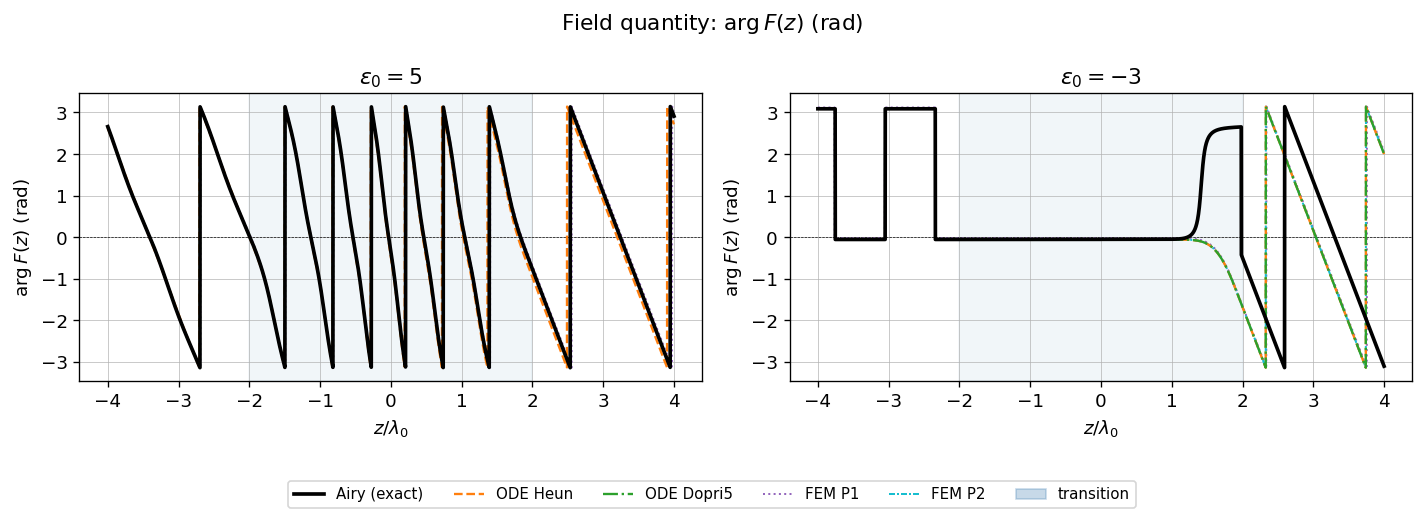

Saved field_angle.png


In [5]:
METHOD_STYLES = {
    'Airy':       dict(color='black',   lw=2.2, ls='-',  zorder=5, label='Airy (exact)'),
    'ODE Heun':   dict(color='#ff7f0e', lw=1.4, ls='--', zorder=4, label='ODE Heun'),
    'ODE Dopri5': dict(color='#2ca02c', lw=1.4, ls='-.',  zorder=4, label='ODE Dopri5'),
    'FEM P1':     dict(color='#9467bd', lw=1.2, ls=':',  zorder=3, label='FEM P1'),
    'FEM P2':     dict(color='#17becf', lw=1.2, ls=(0,(3,1,1,1)), zorder=3, label='FEM P2'),
}

def _interp(res, z_ref):
    """Interpolate result['field'] onto z_ref."""
    z, F = res['z'], res['field']
    Fr = np.interp(z_ref, z, F.real)
    Fi = np.interp(z_ref, z, F.imag)
    return Fr + 1j * Fi

QUANTITIES = [
    ('abs',   r'$|F(z)|$',           np.abs,   'field_abs.png'),
    ('real',  r'$\mathrm{Re}\,F(z)$', np.real,  'field_real.png'),
    ('angle', r'$\arg F(z)$ (rad)',   np.angle, 'field_angle.png'),
]

for qty_key, qty_label, qty_fn, fname in QUANTITIES:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), sharey=False)

    for ax, eps0 in zip(axes, EPS0_CASES):
        # Analytical Airy
        st = METHOD_STYLES['Airy']
        ax.plot(z_dom / lambda0, qty_fn(airy_fields[eps0]), **st)

        # Numerical methods – interpolate to z_dom
        for mkey in ['ODE Heun', 'ODE Dopri5', 'FEM P1', 'FEM P2']:
            F_num = _interp(num_results[eps0][mkey], z_dom)
            st = METHOD_STYLES[mkey]
            ax.plot(z_dom / lambda0, qty_fn(F_num), **st)

        ax.axvspan(-delta/lambda0, delta/lambda0, alpha=0.07, color='steelblue',
                   label='transition')
        ax.axhline(0, lw=0.4, color='k', ls='--')
        ax.set_xlabel(r'$z/\lambda_0$')
        ax.set_ylabel(qty_label)
        ax.set_title(CASE_LABELS[eps0])
        ax.grid(True, lw=0.4)

    # Shared legend below
    handles = [Line2D([0],[0], **METHOD_STYLES[m]) for m in METHOD_STYLES]
    handles += [mpatches.Patch(alpha=0.3, color='steelblue', label='transition')]
    fig.legend(handles=handles, loc='lower center', ncol=6,
               bbox_to_anchor=(0.5, -0.07), fontsize=9)
    fig.suptitle(f'Field quantity: {qty_label}', fontsize=13)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

## Convergence vs `res_trans` (V-shaped profile, θ = 45°, TE)

**Profile:** same V-shaped εr as above (both ε₀ = 5 and ε₀ = −3).
Incident angle θ = 45°, TE (S) polarisation.

**Reference:** Airy analytical solution (exact for piecewise-linear segments).

**Metric 1:** |r_num − r_Airy| — error in complex reflection coefficient.

**Metric 2:** Relative L2 error of the field in the transition layer [−δ, δ]:
$$\epsilon = \frac{\|F_{\rm num}(z) - F_{\rm Airy}(z)\|_2}{\|F_{\rm Airy}(z)\|_2}$$

**ODE solvers** run with `fixed_step=True` so `res_trans` directly controls step count.
(Exception: KenCarp4 is IMEX — its fixed-step flag is ignored; Dopri5 adaptive shown for reference.)
`SemiImplicitEuler` is always fixed-step (symplectic, order 1).

Step size: $h = (z_2 - z_1)/n_{\rm trans}$, where $z_2 - z_1 = 4\lambda_0$.

In [6]:
import contextlib, io
from matplotlib.lines import Line2D

airy_sols_45  = {}
airy_trans_45 = {}  # field on z_trans grid (inside layer, common reference)
for eps0 in EPS0_CASES:
    sol = solve_v_profile(eps0, delta, k0, kx=kx_conv)
    F   = full_field_v_profile(z_trans, eps0, delta, k0, kx=kx_conv, sol=sol)
    airy_sols_45[eps0]  = sol
    airy_trans_45[eps0] = np.asarray(F)
    print(f'eps0={eps0:+d}: r={sol["r"]:.6f}  |r|={abs(sol["r"]):.8f}')

# ── Convergence sweep parameters ─────────────────────────────────────────────
RES_CONV = np.logspace(2,12, num=11,endpoint=True,base=2)   # cells per λ₀ in transition layer

CONV_STYLES = {
    'ODE Heun':              dict(color='#E65100', ls='--',          marker='o',  label='ODE Heun (2nd, fixed)'),
    'ODE Tsit5':             dict(color='#1f77b4', ls='-.',          marker='s',  label='ODE Tsit5 (5th, fixed)'),
    'ODE Dopri5':            dict(color='#2ca02c', ls='-',           marker='^',  label='ODE Dopri5 (5th, fixed)'),
    'ODE KenCarp4':          dict(color='#9467bd', ls=(0,(5,2)),     marker='D',  label='ODE KenCarp4 (4th, IMEX)'),
    'ODE SemiImpEuler':      dict(color='#B71C1C', ls=':',           marker='v',  label='ODE SemiImpEuler (1st)'),
    'FEM P1':                dict(color='#8c564b', ls='--',          marker='<',  label='FEM P1 (2nd)'),
    'FEM P2':                dict(color='#17becf', ls=(0,(3,1,1,1)), marker='>',  label='FEM P2 (4th)'),
}

ODE_METHODS = [
    ('ODE Heun',         'Heun',              True),
    ('ODE Tsit5',        'Tsit5',             True),
    ('ODE Dopri5',       'Dopri5',            True),
    ('ODE KenCarp4',     'KenCarp4',          True),
    ('ODE SemiImpEuler', 'SemiImplicitEuler', True),
]
FEM_METHODS = [
    ('FEM P1', 1),
    ('FEM P2', 2),
]

eps0=+5: r=0.040361+0.041593j  |r|=0.05795708
eps0=-3: r=0.994121-0.108273j  |r|=1.00000000


In [7]:
r_errors   = {(eps0, mkey): [] for eps0 in EPS0_CASES for mkey in CONV_STYLES}
l2_errors  = {(eps0, mkey): [] for eps0 in EPS0_CASES for mkey in CONV_STYLES}
h_vals_conv = {eps0: [] for eps0 in EPS0_CASES}

for eps0 in EPS0_CASES:
    print(f'\n=== Convergence  eps0={eps0}  theta={THETA_CONV}°  TE ===')
    eps_f     = eps_func_v(eps0, delta)
    r_ref     = airy_sols_45[eps0]['r']
    F_ref     = airy_trans_45[eps0]
    norm_ref  = np.linalg.norm(F_ref)

    with contextlib.redirect_stdout(io.StringIO()):
        sv = HelmholtzSolver1D(eps_f, z1, z2, theta_deg=THETA_CONV, pol='S', lambda0=lambda0)

    # Compute step sizes (identical for ODE and FEM given same res_trans)
    h_list = [(z2 - z1) / sv._res_to_n(float(r), z2 - z1) for r in RES_CONV]
    h_vals_conv[eps0] = h_list

    for res, h in zip(RES_CONV, h_list):
        res_f     = float(res)
        res_ext_f = float(max(5, res // 2))

        # ── ODE methods ───────────────────────────────────────────────────────
        for mkey, sname, fstep in ODE_METHODS:
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    result = sv.solve_ode(res_trans=res_f, res_ext=res_ext_f,
                                          solver_name=sname, fixed_step=fstep)
                r_err = abs(result['r'] - r_ref)
                z_n   = np.array(result['z'])
                F_n   = np.array(result['field'])
                mask  = (z_n >= z1 - 1e-10) & (z_n <= z2 + 1e-10)
                F_int = (np.interp(z_trans, z_n[mask], F_n[mask].real)
                         + 1j * np.interp(z_trans, z_n[mask], F_n[mask].imag))
                l2_err = np.linalg.norm(F_int - F_ref) / norm_ref
            except Exception as e:
                r_err, l2_err = np.nan, np.nan
            r_errors[(eps0, mkey)].append(r_err)
            l2_errors[(eps0, mkey)].append(l2_err)

        # ── FEM methods ───────────────────────────────────────────────────────
        for mkey, order in FEM_METHODS:
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    result = sv.solve_fem(res_trans=res_f, res_ext=res_ext_f, order=order)
                r_err = abs(result['r'] - r_ref)
                z_n   = np.array(result['z'])
                F_n   = np.array(result['field'])
                mask  = (z_n >= z1 - 1e-10) & (z_n <= z2 + 1e-10)
                F_int = (np.interp(z_trans, z_n[mask], F_n[mask].real)
                         + 1j * np.interp(z_trans, z_n[mask], F_n[mask].imag))
                l2_err = np.linalg.norm(F_int - F_ref) / norm_ref
            except Exception as e:
                r_err, l2_err = np.nan, np.nan
            r_errors[(eps0, mkey)].append(r_err)
            l2_errors[(eps0, mkey)].append(l2_err)

        print(f'  res={res}  h={h}:  ' +
              '  '.join(f'{k.split()[-1]}|r|={r_errors[(eps0,k)][-1]:.1e}'
                        for k in CONV_STYLES), flush=True)


=== Convergence  eps0=5  theta=45.0°  TE ===
  res=4.0  h=0.25:  Heun|r|=3.2e-01  Tsit5|r|=8.2e-02  Dopri5|r|=1.0e-01  KenCarp4|r|=8.1e-08  SemiImpEuler|r|=1.0e+00  P1|r|=5.6e-01  P2|r|=6.4e-01
  res=8.0  h=0.125:  Heun|r|=9.7e-02  Tsit5|r|=4.1e-03  Dopri5|r|=1.2e-02  KenCarp4|r|=5.4e-08  SemiImpEuler|r|=2.9e-01  P1|r|=2.7e-01  P2|r|=1.3e-02
  res=16.0  h=0.0625:  Heun|r|=1.6e-01  Tsit5|r|=7.6e-05  Dopri5|r|=3.2e-04  KenCarp4|r|=3.9e-08  SemiImpEuler|r|=2.3e-01  P1|r|=2.1e-01  P2|r|=2.3e-03
  res=32.0  h=0.03125:  Heun|r|=1.1e-01  Tsit5|r|=5.0e-05  Dopri5|r|=1.7e-06  KenCarp4|r|=5.4e-08  SemiImpEuler|r|=6.8e-02  P1|r|=5.8e-02  P2|r|=4.3e-04
  res=64.0  h=0.015625:  Heun|r|=3.0e-02  Tsit5|r|=2.6e-05  Dopri5|r|=2.3e-06  KenCarp4|r|=6.0e-08  SemiImpEuler|r|=2.4e-02  P1|r|=1.5e-02  P2|r|=9.9e-05
  res=128.0  h=0.0078125:  Heun|r|=7.6e-03  Tsit5|r|=9.3e-06  Dopri5|r|=1.2e-06  KenCarp4|r|=8.6e-08  SemiImpEuler|r|=1.0e-02  P1|r|=3.6e-03  P2|r|=2.4e-05
  res=256.0  h=0.00390625:  Heun|r|=1.9e

W0508 22:24:24.572897  547419 hlo_rematerialization.cc:3233] Can't reduce memory use below 15.87GiB (17043475606 bytes) by rematerialization; only reduced to 18.00GiB (19326271528 bytes), down from 18.00GiB (19326271528 bytes) originally
W0508 22:24:34.845447  547419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.00GiB (rounded to 19325880320)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0508 22:24:34.845641  547419 bfc_allocator.cc:513] *___________________________________________________________________________________________________


  res=2048.0  h=0.00048828125:  Heun|r|=2.9e-05  Tsit5|r|=1.5e-07  Dopri5|r|=1.5e-07  KenCarp4|r|=8.5e-08  SemiImpEuler|r|=5.7e-04  P1|r|=1.4e-05  P2|r|=nan


W0508 22:25:45.846197  547419 hlo_rematerialization.cc:3233] Can't reduce memory use below 15.87GiB (17043195441 bytes) by rematerialization; only reduced to 18.00GiB (19327844380 bytes), down from 18.00GiB (19327844380 bytes) originally
W0508 22:25:56.010980  547419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.00GiB (rounded to 19327354368)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0508 22:25:56.011194  547419 bfc_allocator.cc:513] *___________________________________________________________________________________________________
W0508 22:25:57.220405  547419 hlo_rematerialization.cc:3233] Can't reduce memory use below 15.87GiB (17043215101 bytes) by rematerialization; only reduced to 72.00GiB (77307248584 bytes), down from 72.00GiB (77307248680 bytes) originally
W050

  res=4096.0  h=0.000244140625:  Heun|r|=7.2e-06  Tsit5|r|=1.4e-07  Dopri5|r|=1.4e-07  KenCarp4|r|=6.8e-08  SemiImpEuler|r|=2.8e-04  P1|r|=nan  P2|r|=nan

=== Convergence  eps0=-3  theta=45.0°  TE ===
  res=4.0  h=0.25:  Heun|r|=2.9e-01  Tsit5|r|=1.3e-03  Dopri5|r|=1.3e-03  KenCarp4|r|=4.4e-08  SemiImpEuler|r|=1.1e+00  P1|r|=7.9e-01  P2|r|=2.2e-01
  res=8.0  h=0.125:  Heun|r|=1.1e-01  Tsit5|r|=2.8e-05  Dopri5|r|=3.2e-05  KenCarp4|r|=4.4e-08  SemiImpEuler|r|=5.2e-01  P1|r|=5.8e-01  P2|r|=5.7e-02
  res=16.0  h=0.0625:  Heun|r|=3.1e-02  Tsit5|r|=4.3e-07  Dopri5|r|=5.3e-07  KenCarp4|r|=4.4e-08  SemiImpEuler|r|=2.6e-01  P1|r|=2.3e-01  P2|r|=1.3e-02
  res=32.0  h=0.03125:  Heun|r|=7.9e-03  Tsit5|r|=6.0e-09  Dopri5|r|=8.4e-09  KenCarp4|r|=4.6e-08  SemiImpEuler|r|=1.3e-01  P1|r|=5.8e-02  P2|r|=3.0e-03
  res=64.0  h=0.015625:  Heun|r|=2.0e-03  Tsit5|r|=7.5e-11  Dopri5|r|=1.3e-10  KenCarp4|r|=4.4e-08  SemiImpEuler|r|=6.8e-02  P1|r|=1.5e-02  P2|r|=7.3e-04
  res=128.0  h=0.0078125:  Heun|r|=5.0e-0

W0508 22:28:32.365916  547419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.00GiB (rounded to 19325880320)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0508 22:28:32.366140  547419 bfc_allocator.cc:513] *___________________________________________________________________________________________________
W0508 22:29:37.131039  547419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.00GiB (rounded to 19327354368)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0508 22:29:37.131278  547419 bfc_allocator.cc:513] *____________________________________________________________

  res=4096.0  h=0.000244140625:  Heun|r|=4.9e-07  Tsit5|r|=1.1e-14  Dopri5|r|=3.8e-15  KenCarp4|r|=4.4e-08  SemiImpEuler|r|=1.1e-03  P1|r|=nan  P2|r|=nan


W0508 22:29:48.120756  547419 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 72.00GiB (rounded to 77306267648)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0508 22:29:48.120968  547419 bfc_allocator.cc:513] *___________________________________________________________________________________________________


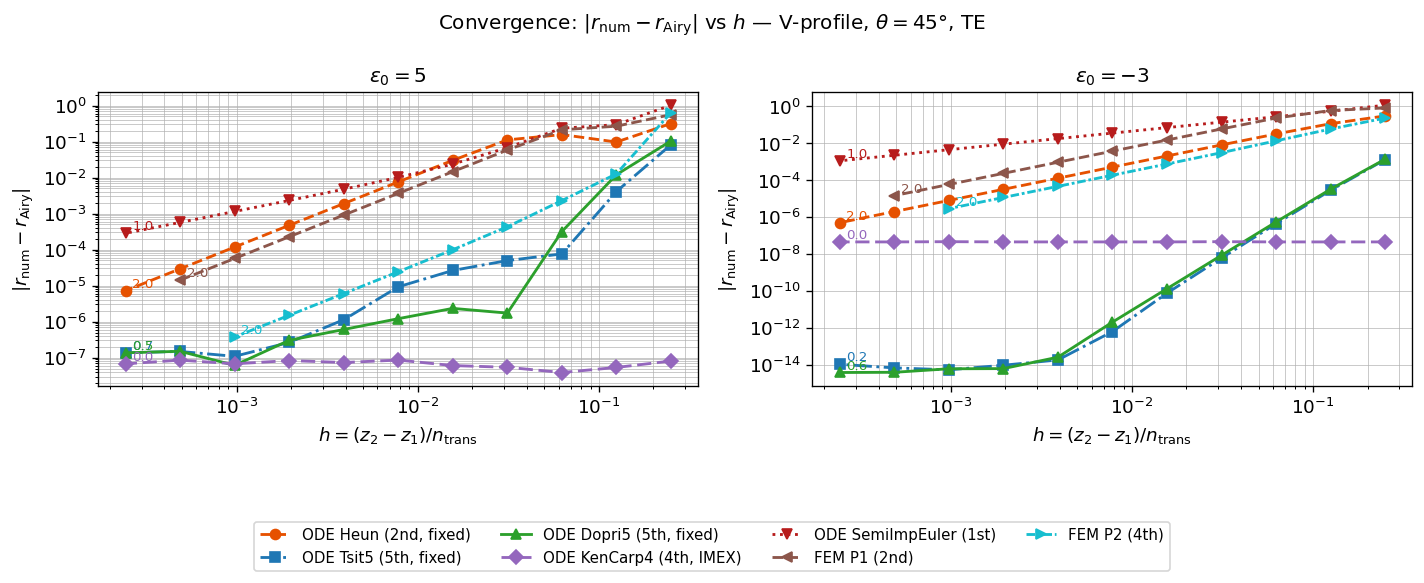

Saved conv_r_error.png


In [8]:
def _legend_handles(include_slopes=False):
    handles = [Line2D([0],[0], color=st['color'], ls=st['ls'],
                       marker=st['marker'], ms=6, lw=1.7, label=st['label'])
               for st in CONV_STYLES.values()]
    if include_slopes:
        for p, ls, lbl in [(1,':','slope 1'),(2,'--','slope 2'),
                            (4,'-.','slope 4'),(5,'-','slope 5')]:
            handles.append(Line2D([0],[0], color='gray', ls=ls, lw=1.0,
                                   alpha=0.7, label=lbl))
    return handles


def _plot_conv(error_dict, ylabel, title_prefix, include_slopes=False, fname=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, eps0 in zip(axes, EPS0_CASES):
        h_arr  = np.array(h_vals_conv[eps0])
        h_ref  = np.array([h_arr[0], h_arr[-1]])
        # pick a y reference from first finite error
        e0 = next((v for mkey in CONV_STYLES
                   for v in [np.array(error_dict[(eps0, mkey)])[np.isfinite(np.array(error_dict[(eps0, mkey)]))]
                              [0:1]] if len(v) > 0), [1e-2])[0]
        for mkey, style in CONV_STYLES.items():
            err = np.array(error_dict[(eps0, mkey)])
            valid = np.isfinite(err) & (err > 1e-16)
            if valid.sum() >= 2:
                ax.loglog(h_arr[valid], err[valid],
                          color=style['color'], ls=style['ls'],
                          marker=style['marker'], ms=6, lw=1.7)
                # annotate fitted slope on finest half
                nf = max(2, valid.sum() // 2)
                hf, ef = h_arr[valid][-nf:], err[valid][-nf:]
                if hf.min() < hf.max():
                    slope = np.polyfit(np.log(hf), np.log(ef), 1)[0]
                    ax.annotate(f'{slope:.1f}', xy=(hf[-1], ef[-1]),
                                xytext=(4, 2), textcoords='offset points',
                                color=style['color'], fontsize=8)
        # reference slopes
        if include_slopes:
            for p, ls in [(1,':'),(2,'--'),(4,'-.'),(5,'-')]:
                ax.loglog(h_ref, e0*(h_ref/h_ref[-1])**p, color='gray',
                        ls=ls, lw=0.9, alpha=0.6)
        ax.set_xlabel(r'$h = (z_2-z_1)/n_{\rm trans}$', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(CASE_LABELS[eps0], fontsize=12)
        ax.grid(True, which='both', lw=0.4)
    fig.suptitle(title_prefix + r' — V-profile, $\theta=45°$, TE', fontsize=12)
    handles = _legend_handles(include_slopes=include_slopes)
    fig.legend(handles=handles, loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, -0.07), fontsize=9)
    plt.tight_layout(rect=[0, 0.14, 1, 1])
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


_plot_conv(
    r_errors,
    r'$|r_{\rm num} - r_{\rm Airy}|$',
    r'Convergence: $|r_{\rm num} - r_{\rm Airy}|$ vs $h$',
    fname='conv_r_error.png',
)

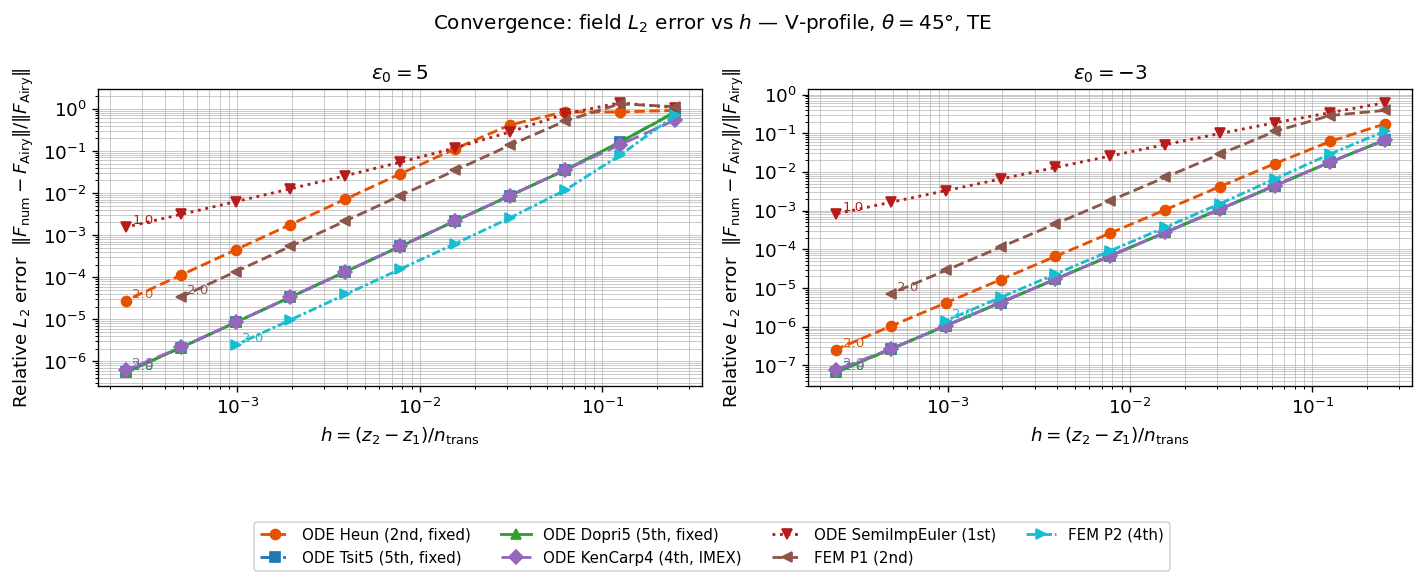

Saved conv_l2_error.png


In [9]:
_plot_conv(
    l2_errors,
    r'Relative $L_2$ error  $\|F_{\rm num}-F_{\rm Airy}\|/\|F_{\rm Airy}\|$',
    r'Convergence: field $L_2$ error vs $h$',
    fname='conv_l2_error.png',
)

## Stability with Negative-ε V-Profile

For $\varepsilon_0 = -3$ the permittivity passes through zero at $|z| = 3\delta/4$, creating two **turning points** in the Helmholtz equation.  
At these points the TM drift term $(1/\varepsilon_r)\,d\varepsilon_r/dz$ diverges — a genuine singularity.

To regularize the singularity while preserving physical meaning we add a small imaginary part:
$$\varepsilon_r(z) \;\to\; \varepsilon_r(z) + j\eta, \qquad |z|\le\delta, \quad \eta = 10^{-4}.$$
This represents a tiny absorption and removes the pole from the real axis.
As $\eta \to 0$ the solution converges to the lossless TM result; $R+T < 1$ by a fraction $\sim\eta$ due to the physical absorption introduced.

**Study 1** — fixed $\varepsilon_0=-3$, $\delta=2\lambda_0$, $\theta=45°$:  
energy residual $|R+T-1|$ vs resolution for all ODE and FEM methods, TE and TM.

**Study 2** — fixed 512 cells/$\lambda_0$, sweep $\delta \in [0.01\lambda_0, 3\lambda_0]$:

- TE: $|r|$ and $\angle r$ vs $\delta$ — Airy (exact) + Dopri5 + FEM P2
- TM: $|r|$ and $\angle r$ vs $\delta$ — Dopri5 + FEM P2 (regularised $\varepsilon$)
- All methods: $|R+T-1|$ vs $\delta$ (TE and TM panels)

In [10]:
# ── Stability study parameters ────────────────────────────────────────────────
EPS0_STAB  = -3
DELTA_STAB = 2.0 * lambda0
THETA_STAB = 45.0
ETA_TM     = 1e-4     # imaginary regularisation for TM at εr=0 crossing


def eps_func_v_tm(eps0, delta, eta=ETA_TM):
    """V-profile + small imaginary part to regularise εr=0 singularity for TM."""
    def _f(z):
        z = float(z)
        if abs(z) <= delta:
            return eps0 + (1.0 - eps0) * abs(z / delta) + 1j * eta
        return 1.0
    return _f


# Quick sanity: εr at turning point before/after regularisation
delta_tmp = DELTA_STAB
z_tp = 0.75 * delta_tmp     # |z| = 3δ/4  →  εr_real = 0
f_te = eps_func_v(EPS0_STAB, delta_tmp)
f_tm = eps_func_v_tm(EPS0_STAB, delta_tmp)
print(f'TE eps at turning point:  {f_te(z_tp)}   (real, zero → TM singularity)')
print(f'TM eps at turning point:  {f_tm(z_tp)}   (regularised, |ε|={abs(f_tm(z_tp)):.2e})')

TE eps at turning point:  0.0   (real, zero → TM singularity)
TM eps at turning point:  0.0001j   (regularised, |ε|=1.00e-04)


In [11]:
# ── Study 1: |R+T-1| vs resolution ───────────────────────────────────────────
# ε0=-3, δ=2λ0, θ=45°; sweep cells/λ0 from 4 to 512
RES_STAB1  = np.logspace(2, 9, num=8, base=2, endpoint=True)   # 4…512

stab1_h   = {}                         # pol → list of h values
stab1_rt  = {}                         # (pol, mkey) → list of R+T

for pol_label, pol_code, eps_f in [
        ('TE', 'S', eps_func_v(EPS0_STAB, DELTA_STAB)),
        ('TM', 'P', eps_func_v_tm(EPS0_STAB, DELTA_STAB)),
]:
    print(f'\n=== Study 1  pol={pol_label}  ε₀={EPS0_STAB}  δ={DELTA_STAB}λ₀  θ={THETA_STAB}° ===')
    with contextlib.redirect_stdout(io.StringIO()):
        sv = HelmholtzSolver1D(eps_f, -DELTA_STAB, DELTA_STAB,
                               theta_deg=THETA_STAB, pol=pol_code, lambda0=lambda0)
        h_list = [(2*DELTA_STAB) / sv._res_to_n(float(r), 2*DELTA_STAB)
                  for r in RES_STAB1]
    stab1_h[pol_label] = h_list

    for mkey in CONV_STYLES:
        stab1_rt[(pol_label, mkey)] = []

    for res, h in zip(RES_STAB1, h_list):
        res_f     = float(res)
        res_ext_f = max(5.0, res_f / 4.0)

        for mkey, sname, fstep in ODE_METHODS:
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    result = sv.solve_ode(res_trans=res_f, res_ext=res_ext_f,
                                          solver_name=sname, fixed_step=fstep)
                    rt = sv.energy_check(result['r'], result['t'])
            except Exception:
                rt = np.nan
            stab1_rt[(pol_label, mkey)].append(rt)

        for mkey, order in FEM_METHODS:
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    result = sv.solve_fem(res_trans=res_f, res_ext=res_ext_f, order=order)
                    rt = sv.energy_check(result['r'], result['t'])
            except Exception:
                rt = np.nan
            stab1_rt[(pol_label, mkey)].append(rt)

        print(f'  res={res_f:.0f}  h={h:.5f}:  '
              + '  '.join(f'{k.split()[-1]}={stab1_rt[(pol_label,k)][-1]:.5f}'
                          for k in CONV_STYLES), flush=True)


=== Study 1  pol=TE  ε₀=-3  δ=2.0λ₀  θ=45.0° ===
  res=4  h=0.25000:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=1.30266  P2=1.00029
  res=8  h=0.12500:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=1.17717  P2=0.99912
  res=16  h=0.06250:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=1.14489  P2=0.99886
  res=32  h=0.03125:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=1.01609  P2=0.99981
  res=64  h=0.01562:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=0.99875  P2=0.99999
  res=128  h=0.00781:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=0.99934  P2=1.00000
  res=256  h=0.00391:  Heun=1.00000  Tsit5=1.00000  Dopri5=1.00000  KenCarp4=1.00000  SemiImpEuler=1.00000  P1=0.99981  P2=1.00000
  res=512  h=0.00195:  Heun=1.00000  Tsi

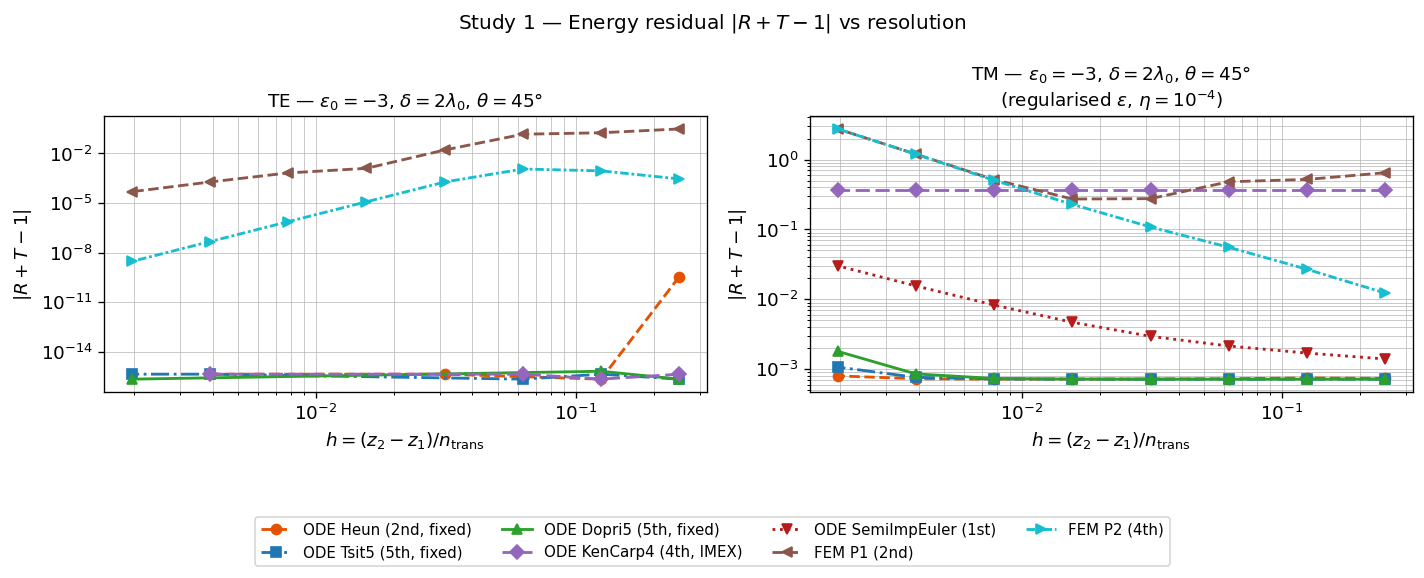

Saved stab1_energy.png


In [12]:
# ── Study 1 plot: |R+T-1| vs resolution for TE and TM ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, pol_label in zip(axes, ['TE', 'TM']):
    h_arr = np.array(stab1_h[pol_label])
    for mkey, style in CONV_STYLES.items():
        vals  = np.array(stab1_rt[(pol_label, mkey)])
        resid = np.abs(vals - 1.0)
        valid = np.isfinite(resid) & (resid > 0)
        if valid.sum() >= 2:
            ax.loglog(h_arr[valid], resid[valid],
                        color=style['color'], ls=style['ls'],
                        marker=style['marker'], ms=6, lw=1.7)
    ax.set_xlabel(r'$h = (z_2-z_1)/n_{\rm trans}$', fontsize=11)
    ax.set_ylabel(r'$|R+T-1|$', fontsize=11)
    ax.set_title(
        f'{pol_label} — '
        + r'$\varepsilon_0=-3$, $\delta=2\lambda_0$, $\theta=45°$'
        + ('\n(regularised $\\varepsilon$, $\\eta=10^{-4}$)' if pol_label == 'TM' else ''),
        fontsize=11)
    ax.grid(True, which='both', lw=0.4)

handles = [Line2D([0],[0], color=st['color'], ls=st['ls'],
                   marker=st['marker'], ms=6, lw=1.7, label=st['label'])
           for st in CONV_STYLES.values()]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle(r'Study 1 — Energy residual $|R+T-1|$ vs resolution', fontsize=12)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.savefig('stab1_energy.png', bbox_inches='tight')
plt.show()
print('Saved stab1_energy.png')

In [13]:
# ── Study 2: δ sweep at fixed 512 cells/λ0, θ=45°, ε0=-3 ────────────────────
RES_FIXED2 = 512.0
DELTA_ARR  = np.logspace(-2, np.log10(3.0), 10) * lambda0   # 0.01–3 λ0
kx_stab    = k0 * np.sin(np.deg2rad(THETA_STAB))             # ε1=1

study2_airy_r = []
study2_airy_t = []
study2_te  = {mkey: {'r': [], 't': [], 'rt': []} for mkey in CONV_STYLES}
study2_tm  = {mkey: {'r': [], 't': [], 'rt': []} for mkey in CONV_STYLES}

for delta_i in DELTA_ARR:
    z1_i, z2_i = -delta_i, delta_i
    res_ext_i  = max(5.0, RES_FIXED2 / 4.0)

    # Airy reference (TE only — exact for piecewise-linear, ε1=ε2=1)
    sol_a = solve_v_profile(EPS0_STAB, delta_i, k0, kx=kx_stab)
    study2_airy_r.append(sol_a['r'])
    study2_airy_t.append(sol_a['t'])

    # TE numerical
    eps_f_te = eps_func_v(EPS0_STAB, delta_i)
    with contextlib.redirect_stdout(io.StringIO()):
        sv_te = HelmholtzSolver1D(eps_f_te, z1_i, z2_i,
                                  theta_deg=THETA_STAB, pol='S', lambda0=lambda0)
    for mkey, sname, fstep in ODE_METHODS:
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                res = sv_te.solve_ode(res_trans=RES_FIXED2, res_ext=res_ext_i,
                                      solver_name=sname, fixed_step=fstep)
                rt  = sv_te.energy_check(res['r'], res['t'])
        except Exception:
            res = {'r': np.nan + 0j, 't': np.nan + 0j}; rt = np.nan
        study2_te[mkey]['r'].append(res['r'])
        study2_te[mkey]['t'].append(res['t'])
        study2_te[mkey]['rt'].append(rt)
    for mkey, order in FEM_METHODS:
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                res = sv_te.solve_fem(res_trans=RES_FIXED2, res_ext=res_ext_i, order=order)
                rt  = sv_te.energy_check(res['r'], res['t'])
        except Exception:
            res = {'r': np.nan + 0j, 't': np.nan + 0j}; rt = np.nan
        study2_te[mkey]['r'].append(res['r'])
        study2_te[mkey]['t'].append(res['t'])
        study2_te[mkey]['rt'].append(rt)

    # TM numerical (regularised ε inside layer)
    eps_f_tm = eps_func_v_tm(EPS0_STAB, delta_i)
    with contextlib.redirect_stdout(io.StringIO()):
        sv_tm = HelmholtzSolver1D(eps_f_tm, z1_i, z2_i,
                                  theta_deg=THETA_STAB, pol='P', lambda0=lambda0)
    for mkey, sname, fstep in ODE_METHODS:
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                res = sv_tm.solve_ode(res_trans=RES_FIXED2, res_ext=res_ext_i,
                                      solver_name=sname, fixed_step=fstep)
                rt  = sv_tm.energy_check(res['r'], res['t'])
        except Exception:
            res = {'r': np.nan + 0j, 't': np.nan + 0j}; rt = np.nan
        study2_tm[mkey]['r'].append(res['r'])
        study2_tm[mkey]['t'].append(res['t'])
        study2_tm[mkey]['rt'].append(rt)
    for mkey, order in FEM_METHODS:
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                res = sv_tm.solve_fem(res_trans=RES_FIXED2, res_ext=res_ext_i, order=order)
                rt  = sv_tm.energy_check(res['r'], res['t'])
        except Exception:
            res = {'r': np.nan + 0j, 't': np.nan + 0j}; rt = np.nan
        study2_tm[mkey]['r'].append(res['r'])
        study2_tm[mkey]['t'].append(res['t'])
        study2_tm[mkey]['rt'].append(rt)

    print(f'  δ={delta_i/lambda0:.3f}λ₀  Airy r={sol_a["r"]:.4f}  '
          f'Dopri5_TE r={study2_te["ODE Dopri5"]["r"][-1]:.4f}  '
          f'Dopri5_TM r={study2_tm["ODE Dopri5"]["r"][-1]:.4f}', flush=True)

  δ=0.010λ₀  Airy r=-0.0154+0.1748j  Dopri5_TE r=-0.0153+0.1747j  Dopri5_TM r=0.0016-0.0459j
  δ=0.019λ₀  Airy r=-0.0510+0.3166j  Dopri5_TE r=-0.0510+0.3166j  Dopri5_TM r=0.0030-0.2280j
  δ=0.036λ₀  Airy r=-0.1461+0.5285j  Dopri5_TE r=-0.1461+0.5284j  Dopri5_TM r=-0.0267-0.4907j
  δ=0.067λ₀  Airy r=-0.2936+0.7498j  Dopri5_TE r=-0.2936+0.7498j  Dopri5_TM r=-0.0825-0.7783j
  δ=0.126λ₀  Airy r=-0.3265+0.9044j  Dopri5_TE r=-0.3265+0.9044j  Dopri5_TM r=-0.9312+0.3945j
  δ=0.238λ₀  Airy r=-0.1264+0.9901j  Dopri5_TE r=-0.1264+0.9901j  Dopri5_TM r=-0.1087-1.0097j
  δ=0.448λ₀  Airy r=0.2292+0.9734j  Dopri5_TE r=0.2292+0.9734j  Dopri5_TM r=-0.2633+1.0521j
  δ=0.845λ₀  Airy r=0.6534+0.7570j  Dopri5_TE r=0.6534+0.7570j  Dopri5_TM r=-0.5977+0.7995j
  δ=1.592λ₀  Airy r=0.9806+0.1962j  Dopri5_TE r=0.9806+0.1962j  Dopri5_TM r=0.1161+0.9972j
  δ=3.000λ₀  Airy r=0.7014-0.7127j  Dopri5_TE r=0.7014-0.7127j  Dopri5_TM r=1.0009+0.0337j


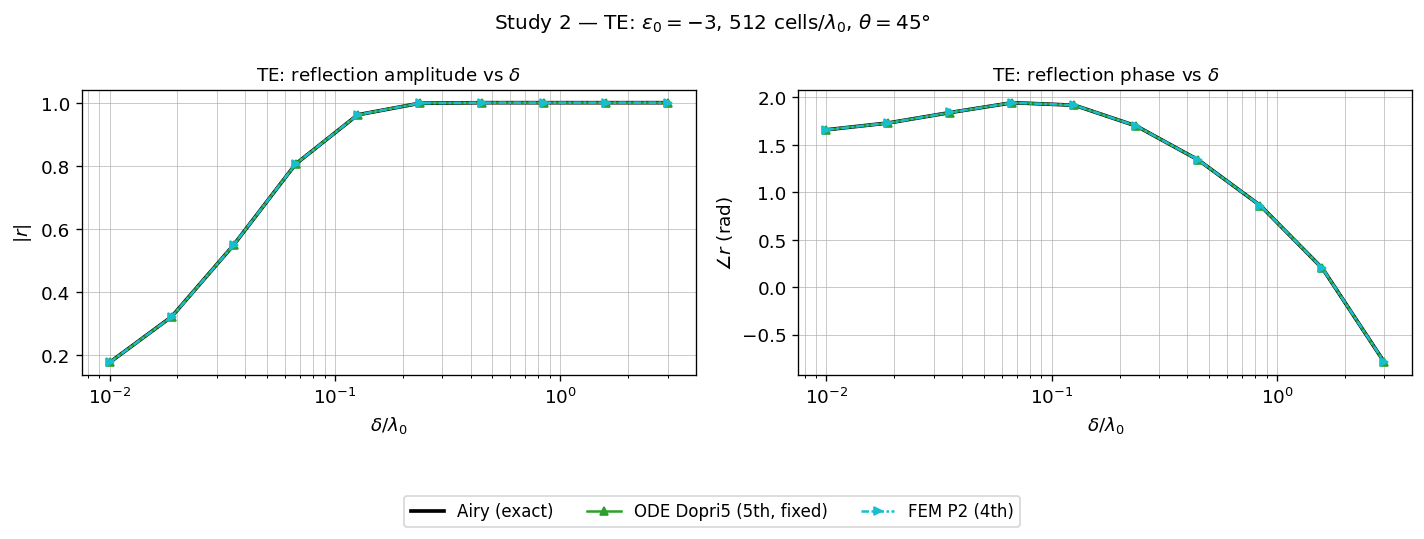

Saved stab2_te.png


In [14]:
# ── Study 2 plot A: TE  |r| and ∠r vs δ ─────────────────────────────────────
d_arr = DELTA_ARR / lambda0
r_airy = np.array(study2_airy_r)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Airy reference
ax1.semilogx(d_arr, np.abs(r_airy),   color='black', lw=2.2, ls='-', label='Airy (exact)')
ax2.semilogx(d_arr, np.angle(r_airy), color='black', lw=2.2, ls='-', label='Airy (exact)')

# Selected numerical methods
for mkey in ['ODE Dopri5', 'FEM P2']:
    st = CONV_STYLES[mkey]
    r_arr = np.array(study2_te[mkey]['r'])
    valid = np.isfinite(np.abs(r_arr))
    ax1.semilogx(d_arr[valid], np.abs(r_arr[valid]),
                 color=st['color'], ls=st['ls'], marker=st['marker'],
                 ms=5, lw=1.5, label=st['label'])
    ax2.semilogx(d_arr[valid], np.angle(r_arr[valid]),
                 color=st['color'], ls=st['ls'], marker=st['marker'],
                 ms=5, lw=1.5, label=st['label'])

for ax, ylabel, title in [
    (ax1, r'$|r|$',          r'TE: reflection amplitude vs $\delta$'),
    (ax2, r'$\angle r$ (rad)', r'TE: reflection phase vs $\delta$'),
]:
    ax.set_xlabel(r'$\delta/\lambda_0$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, which='both', lw=0.4)

handles = ([Line2D([0],[0], color='black', lw=2.2, label='Airy (exact)')] +
           [Line2D([0],[0], color=CONV_STYLES[m]['color'], ls=CONV_STYLES[m]['ls'],
                   marker=CONV_STYLES[m]['marker'], ms=5, lw=1.5,
                   label=CONV_STYLES[m]['label'])
            for m in ['ODE Dopri5', 'FEM P2']])
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)
fig.suptitle(r'Study 2 — TE: $\varepsilon_0=-3$, 512 cells/$\lambda_0$, $\theta=45°$',
             fontsize=12)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('stab2_te.png', bbox_inches='tight')
plt.show()
print('Saved stab2_te.png')

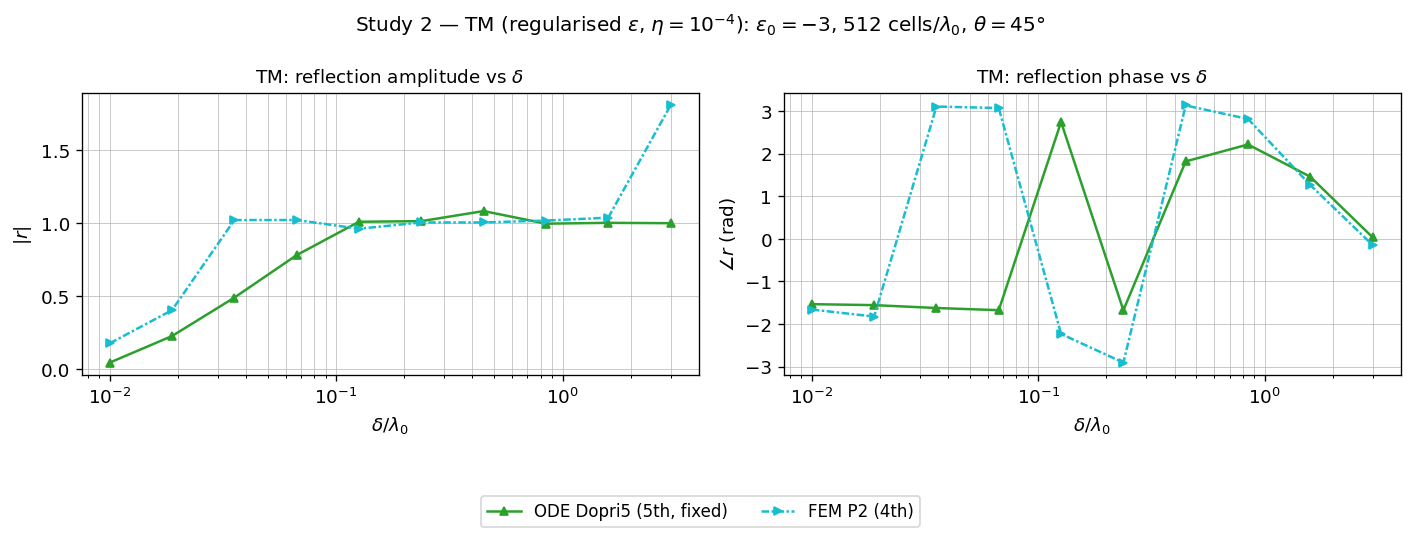

Saved stab2_tm.png


In [15]:
# ── Study 2 plot B: TM  |r| and ∠r vs δ (regularised ε) ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for mkey in ['ODE Dopri5', 'FEM P2']:
    st = CONV_STYLES[mkey]
    r_arr = np.array(study2_tm[mkey]['r'])
    valid = np.isfinite(np.abs(r_arr))
    ax1.semilogx(d_arr[valid], np.abs(r_arr[valid]),
                 color=st['color'], ls=st['ls'], marker=st['marker'],
                 ms=5, lw=1.5, label=st['label'])
    ax2.semilogx(d_arr[valid], np.angle(r_arr[valid]),
                 color=st['color'], ls=st['ls'], marker=st['marker'],
                 ms=5, lw=1.5, label=st['label'])

for ax, ylabel, title in [
    (ax1, r'$|r|$',           r'TM: reflection amplitude vs $\delta$'),
    (ax2, r'$\angle r$ (rad)', r'TM: reflection phase vs $\delta$'),
]:
    ax.set_xlabel(r'$\delta/\lambda_0$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, which='both', lw=0.4)

handles = [Line2D([0],[0], color=CONV_STYLES[m]['color'], ls=CONV_STYLES[m]['ls'],
                   marker=CONV_STYLES[m]['marker'], ms=5, lw=1.5,
                   label=CONV_STYLES[m]['label'])
           for m in ['ODE Dopri5', 'FEM P2']]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)
fig.suptitle(
    r'Study 2 — TM (regularised $\varepsilon$, $\eta=10^{-4}$): '
    r'$\varepsilon_0=-3$, 512 cells/$\lambda_0$, $\theta=45°$',
    fontsize=12)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('stab2_tm.png', bbox_inches='tight')
plt.show()
print('Saved stab2_tm.png')

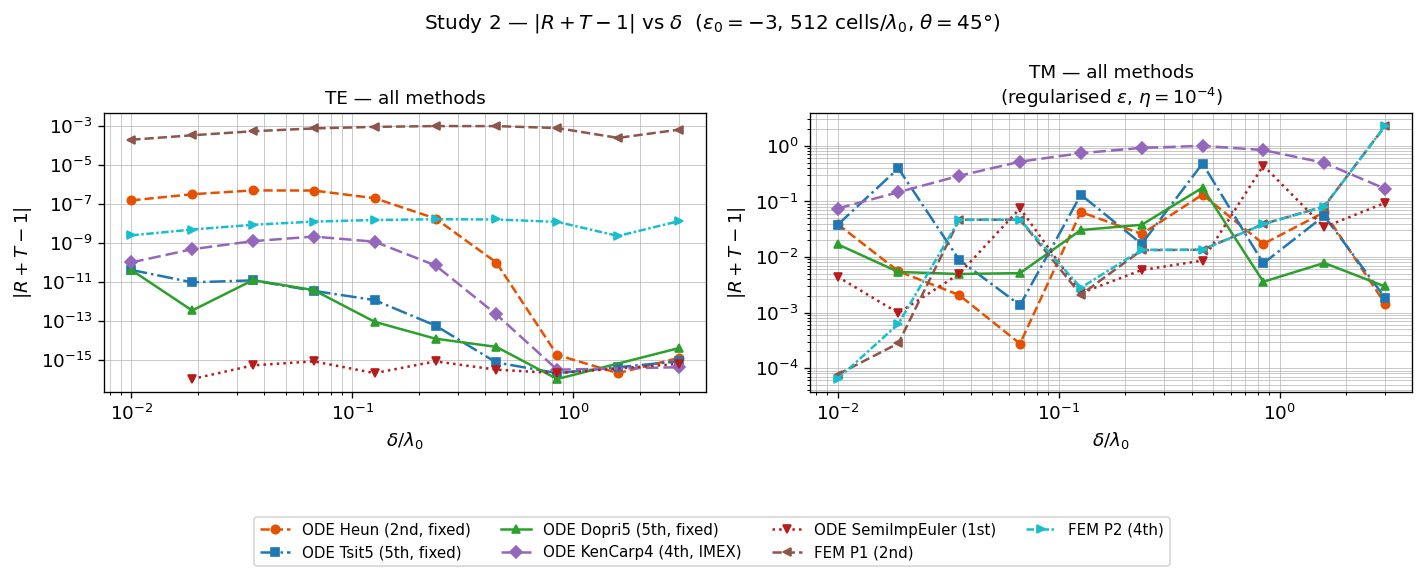

Saved stab2_energy.png


In [16]:
# ── Study 2 plot C: |R+T-1| vs δ for all methods (TE and TM) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, pol_label, study_dict in [
    (axes[0], 'TE', study2_te),
    (axes[1], 'TM', study2_tm),
]:
    for mkey, style in CONV_STYLES.items():
        rt_arr = np.array(study_dict[mkey]['rt'])
        resid  = np.abs(rt_arr - 1.0)
        valid  = np.isfinite(resid) & (resid > 0)
        if valid.sum() >= 2:
            ax.semilogy(d_arr[valid], resid[valid],
                        color=style['color'], ls=style['ls'],
                        marker=style['marker'], ms=5, lw=1.5)
    ax.set_xlabel(r'$\delta/\lambda_0$', fontsize=11)
    ax.set_ylabel(r'$|R+T-1|$', fontsize=11)
    ax.set_title(
        f'{pol_label} — all methods'
        + ('\n(regularised $\\varepsilon$, $\\eta=10^{-4}$)' if pol_label == 'TM' else ''),
        fontsize=11)
    ax.set_xscale('log')
    ax.grid(True, which='both', lw=0.4)

handles = [Line2D([0],[0], color=st['color'], ls=st['ls'],
                   marker=st['marker'], ms=5, lw=1.5, label=st['label'])
           for st in CONV_STYLES.values()]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle(
    r'Study 2 — $|R+T-1|$ vs $\delta$  ($\varepsilon_0=-3$, 512 cells/$\lambda_0$, $\theta=45°$)',
    fontsize=12)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.savefig('stab2_energy.png', bbox_inches='tight')
plt.show()
print('Saved stab2_energy.png')